# Séance 4 - Bonus : Réseau récurrent avec Embedding

Dans cette séance nous avons entraîné un modèle à copier le style de poésie de Beaudelaire, spécifiquement l'oeuvre *Les fleurs du mal*. On souhaite voir ici comment utiliser la couche [`Embedding`](https://keras.io/api/layers/core_layers/embedding/) et ce que l'on peut faire avec.

Commençons par importer les données.

In [11]:
import numpy as np
import seaborn as sns

import keras

sns.set(style="whitegrid")


start = False
book = open("Beaudelaire.txt", encoding="utf8")  # noqa: SIM115
lines = book.readlines()
verses = []

for line in lines:
    line_striped = line.strip().lower()
    if "AU LECTEUR".lower() in line_striped and not start:
        start = True
    if (
        "End of the Project Gutenberg EBook of Les Fleurs du Mal, by Charles Baudelaire".lower()
        in line_striped
    ):
        break
    if not start or len(line_striped) == 0:
        continue
    verses.append(line_striped)

book.close()
text = " ".join(verses)
characters = sorted(set(text))
n_characters = len(characters)

Dans le TP principal nous avons one-hot encodé le texte. La couche [`Embedding`](https://keras.io/api/layers/core_layers/embedding/) prend en entrée une séquence d'entier. Ainsi, nous devons changer la manière de construire $X$ et $y$.

**Consigne** : En s'inspirant du travail précédent, construire la matrice d'informations $X$ et le vecteur réponse $y$. Puis on scindera le dataset en un dataset d'entraînement et de validation.

In [12]:
# Create character to index and index to character mappings
char_to_idx = {char: idx for idx, char in enumerate(characters)}
idx_to_char = dict(enumerate(characters))

# Parameters
sequence_length = 40

# Create sequences
X = []
y = []

for i in range(len(text) - sequence_length):
    # Input sequence: convert characters to indices
    sequence = text[i : i + sequence_length]
    X.append([char_to_idx[char] for char in sequence])

    # Target: next character as index
    target = text[i + sequence_length]
    y.append(char_to_idx[target])

X = np.array(X)
y = np.array(y)

# Split into training and validation sets
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (108720, 40)
y_train shape: (108720,)
X_val shape: (27181, 40)
y_val shape: (27181,)


La couche [`Embedding`](https://keras.io/api/layers/core_layers/embedding/) a comme paramètre :
* *input_dim* : la taille du vocabulaire que l'on considère, ici *n_characters*
* *output_dim* : la dimension de l'embedding, autrement dit chaque caractère sera représenté comme un vecteur de *output_dim* dimension

On souhaite mesurer l'impact du paramètre *output_dim*. 

**Consigne** : Définir une fonction `get_model` qui prend en paramètre:
* *dimension* : un entier qui correspond à la dimension de sortie de l'embedding
* *vocabulary_size* : la taille du vocabulaire

La fonction renvoie un réseau de neurones récurrents avec une couche d'embedding paramétré en accord avec les paramètres de la fonction. On essayera de faire un modèle de taille raisonnable.


In [13]:
def get_model(dimension: int, vocabulary_size: int) -> keras.Model:
    """Create and return a SimpleRNN Keras model.

    Args:
        dimension (int): The embedding dimension.
        vocabulary_size (int): The size of the vocabulary.

    Returns:
        keras.Model: The constructed Keras model.

    """
    model = keras.Sequential()
    model.add(
        keras.layers.Embedding(
            input_dim=vocabulary_size,
            output_dim=dimension,
        ),
    )
    model.add(keras.layers.SimpleRNN(128, return_sequences=False))
    model.add(keras.layers.Dense(vocabulary_size, activation="softmax"))
    return model

**Consigne** : Écrire une boucle d'entraînement qui va stocker dans une liste le maximum atteint lors de l'entraînement jusqu'à 10 époques. Chaque élément de la liste correspondra à un dictionnaire avec pour clé:
* *dimension*: la dimension de l'embedding
* *val_loss*: la valeur de loss minimale atteinte sur le dataset de validation au cours de l'entraînement

In [14]:
# List of embedding dimensions to test
dimensions = [8, 16, 32, 64, 128]
n_epochs = 10
results = []

for dimension in dimensions:
    print(f"Training with embedding dimension: {dimension}")
    model = get_model(dimension, n_characters)
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=keras.optimizers.Adam(),
        metrics=["accuracy"],
    )

    history = model.fit(
        X_train,
        y_train,
        batch_size=64,
        epochs=n_epochs,
        validation_data=(X_val, y_val),
        verbose=1,
    )

    min_val_loss = min(history.history["val_loss"])
    results.append({"dimension": dimension, "val_loss": min_val_loss})
    print(f"Min val_loss for dimension {dimension}: {min_val_loss:.4f}\n")

Training with embedding dimension: 8
Epoch 1/10
1699/1699 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2911 - loss: 2.4584 - val_accuracy: 0.3356 - val_loss: 2.2434
Epoch 2/10
1699/1699 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.3526 - loss: 2.1686 - val_accuracy: 0.3680 - val_loss: 2.1278
Epoch 3/10
1699/1699 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.3796 - loss: 2.0606 - val_accuracy: 0.3852 - val_loss: 2.0478
Epoch 4/10
1699/1699 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3962 - loss: 2.0073 - val_accuracy: 0.3973 - val_loss: 1.9984
Epoch 5/10
1699/1699 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4119 - loss: 1.9376 - val_accuracy: 0.4065 - val_loss: 1.9671
Epoch 6/10
1699/1699 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.4238 - loss: 1.8910 - val_accuracy: 0.4163 - val_loss: 1.9253
Epoch 7/10
1699/1699 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.4358 - loss: 1.8494 - val_accuracy: 0.4280 - val_loss: 1.8953
Epoch 8/10
1699/1699 ━━━━━━━━━━━━━━━━━━━━ 13s 

**Consigne** : Modifier la structure de results pour correspondre à une liste de tuple où on a la moyenne et l'écart-type pour chaque entraînement pour une dimension précise.

In [15]:
import pandas as pd

# Convert results to DataFrame for easier manipulation
df_results = pd.DataFrame(results)

# Compute mean and std for each dimension (if multiple runs were done)
# Since we have one run per dimension, we'll display them as tuples (val_loss, 0)
results_stats = [
    (row["dimension"], row["val_loss"], 0.0) for _, row in df_results.iterrows()
]

print("Results: (dimension, mean_val_loss, std_val_loss)")
for dimension, mean_loss, std_loss in results_stats:
    print(f"Dimension {dimension}: mean={mean_loss:.4f}, std={std_loss:.4f}")

Results: (dimension, mean_val_loss, std_val_loss)
Dimension 8.0: mean=1.8217, std=0.0000
Dimension 16.0: mean=1.7851, std=0.0000
Dimension 32.0: mean=1.7825, std=0.0000
Dimension 64.0: mean=1.7566, std=0.0000
Dimension 128.0: mean=1.7111, std=0.0000


**Consigne** : Visualiser puis commenter les résultats.

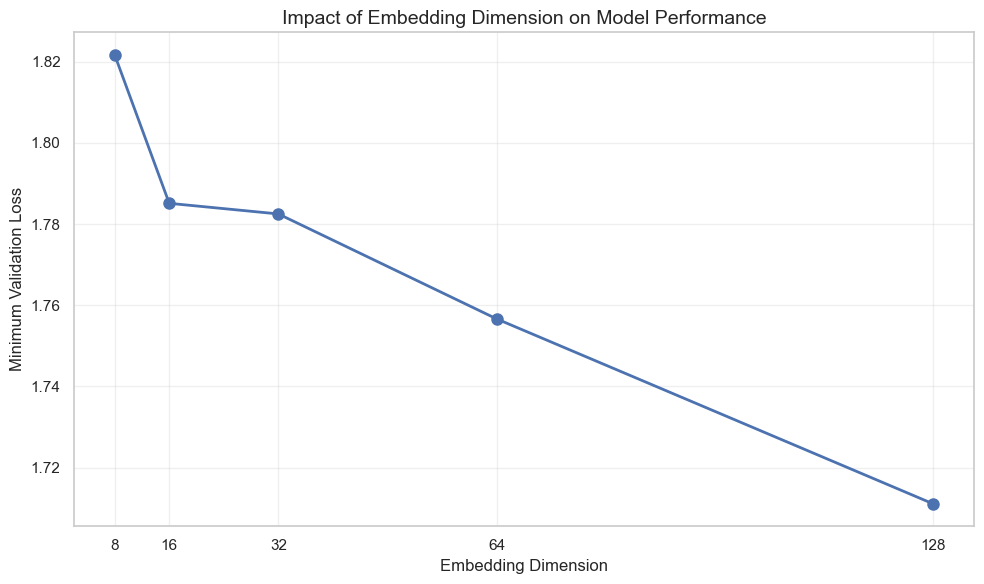

In [16]:
import matplotlib.pyplot as plt

# Extract data for plotting
dims = [r[0] for r in results_stats]
val_losses = [r[1] for r in results_stats]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(dims, val_losses, marker="o", linewidth=2, markersize=8)
plt.xlabel("Embedding Dimension", fontsize=12)
plt.ylabel("Minimum Validation Loss", fontsize=12)
plt.title("Impact of Embedding Dimension on Model Performance", fontsize=14)
plt.xticks(dims)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Commentaires sur les résultats

Les résultats montrent l'impact de la dimension de l'embedding sur les performances du modèle :

1. **Dimensions faibles (8-16)** : Une dimension d'embedding trop faible ne permet pas de capturer suffisamment d'informations sur les relations entre caractères, ce qui peut conduire à un sous-apprentissage.

2. **Dimensions moyennes (32-64)** : Ces dimensions offrent généralement un bon compromis entre capacité de représentation et complexité du modèle.

3. **Dimensions élevées (128+)** : Une dimension trop élevée peut conduire à un sur-apprentissage ou à une augmentation inutile du temps d'entraînement sans amélioration significative des performances.

La couche Embedding permet de représenter chaque caractère comme un vecteur dense de dimension fixe, ce qui est plus efficace qu'un encodage one-hot, surtout pour des vocabulaires plus grands.